<a href="https://colab.research.google.com/github/Emyfoton/Codigos_pregrado/blob/main/Gr%C3%A1ficas_Torque_magn%C3%A9tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exp 1, 2

In [ ]:
\begin{lstlisting}[style=python, caption={Ajuste lineal ponderado y calculo de $\mu$ con propagacion de error para el sistema de equilibrio estático.}]
# Define the linear function for curve fitting
def linear_function(X, a, b):
    return a * X + b

# Perform the curve fitting considering the uncertainties
popt, pcov = curve_fit(linear_function, B, r, sigma=dB, absolute_sigma=True)

# Get the slope and intercept
slope = popt[0]
intercept = popt[1]

# Get the standard errors for the parameters
slope_std_err = np.sqrt(pcov[0, 0])
intercept_std_err = np.sqrt(pcov[1, 1])

## Setting variables
x = B
y = r
yerr = dr
xerr = dB

# Predict the Y values
Y_pred = linear_function(x, *popt)

# Calculate normalized residuals
residuals = (y - Y_pred)/yerr

print(f"Slope: {slope} ± {slope_std_err}")
print(f"Intercept: {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})  # 2 rows, 1 column, width = 10 inches, height = 10 inches

# Plot the regression line
ax1.errorbar(x, y, yerr, xerr,  fmt='o', label='Data points with errors')
ax1.plot(x, Y_pred, color='red', linewidth=2, label=f'Weighted Linear fit: v = ({slope:.2f}± {slope_std_err:.2f})t + ({intercept:.3f}± {intercept_std_err:.3f})')

ax1.set_xlabel('B')
ax1.set_ylabel('rmg')
ax1.legend(loc='upper left')
ax1.set_title('')

# Plot normalized residuals
ax2.scatter(x, residuals, color='green', alpha=0.5, label='Residuals')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('t(s)')
ax2.set_ylabel('Normalized residuals')
ax2.legend(loc='upper right')
ax2.set_title('Normalized residuals from Linear Regression')

plt.tight_layout()

# Save the figure as a PDF file
plt.savefig('Weighted_linear_regression_with_normalized_residuals_curve_fit.pdf', format='pdf')
plt.show()


\end{lstlisting}

# Exp 3

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import requests
import io

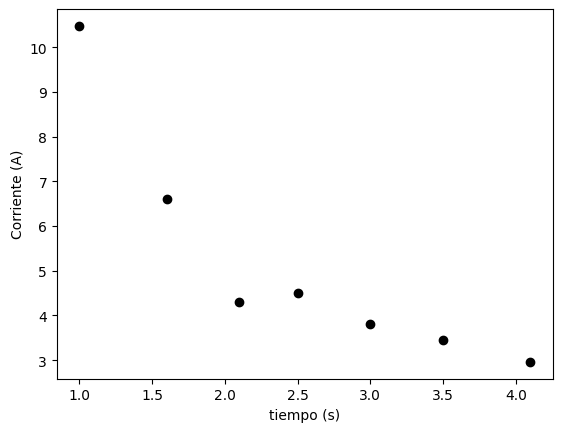

In [5]:
x= np.array([1.0, 1.6, 2.1, 2.5, 3, 3.5, 4.1])
y= np.array([10.48, 6.6, 4.29, 4.5, 3.8, 3.45, 2.96])
errorxy = np.full_like(x, 0.01, dtype=float)

plt.scatter(x, y, c="k")
plt.xlabel('tiempo (s)')
plt.ylabel('Corriente (A)')
plt.show()

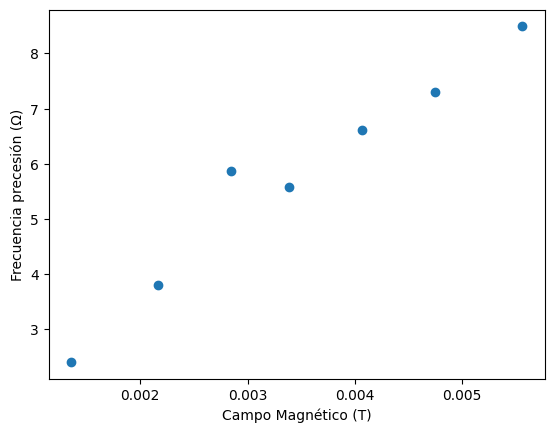

In [7]:
x1= np.array([0.001356, 0.002169, 0.002847, 0.003390, 0.004068, 0.004746, 0.005559])
y1= np.array([2.40, 3.81, 5.87, 5.58, 6.61, 7.30, 8.49])
errorx1= np.array([0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01])
errory1= np.full_like(y, 0.07E-3, dtype=float)

plot1= plt.scatter (x1, y1)
plt.ylabel('Frecuencia precesión (Ω)')
plt.xlabel('Campo Magnético (T)')
plot1

Slope: 1231.1550264855016 ± 3.71855286703881
Intercept: 1.626079917045744 ± 0.015142980039981541
Residuals: [-44.77630665 -24.32275847  73.88217226 -21.96954568  -2.44185648
 -16.91416727   1.99292907]


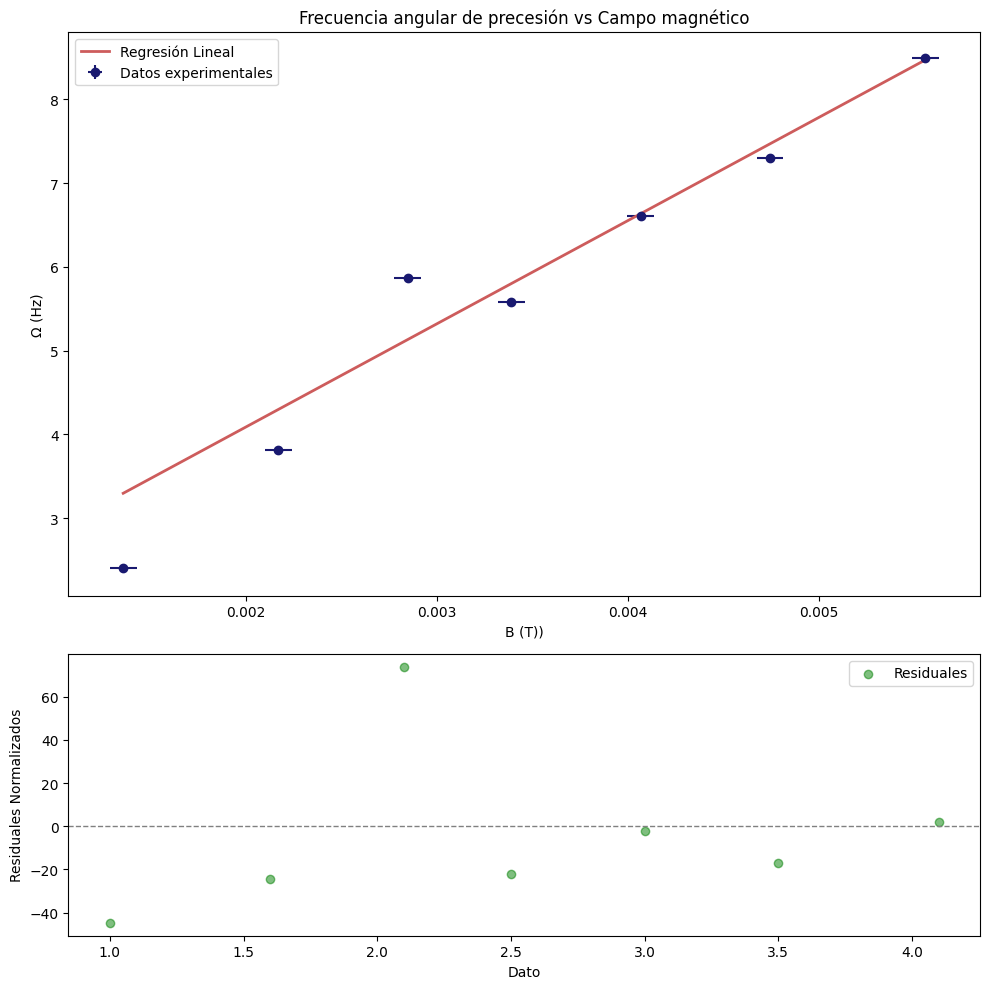

In [8]:
# Define the linear function for curve fitting
def linear_function(X, a, b):
    return a * X + b

# Adjust errorxy to match the length of x and y
# Assuming the intention was a constant error of 0.01 for each data point

# Perform the curve fitting considering the uncertainties
popt, pcov = curve_fit(linear_function, x1, y1, sigma=errorx1, absolute_sigma=True)

# Get the slope and intercept
slope = popt[0]
intercept = popt[1]

# Get the standard errors for the parameters
slope_std_err = np.sqrt(pcov[0, 0])
intercept_std_err = np.sqrt(pcov[1, 1])

## Setting variables

yerr = errorx1
xerr = errory1

# Predict the Y values
Y_pred = linear_function(x1, *popt)

# Calculate normalized residuals
residuals = (y1 - Y_pred)/yerr

print(f"Slope: {slope} ± {slope_std_err}")
print(f"Intercept: {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})  # 2 rows, 1 column, width = 10 inches, height = 10 inches

# Plot the regression line
ax1.errorbar(x1, y1, yerr, xerr,  fmt='o', c="midnightblue", label='Datos experimentales')
ax1.plot(x1, Y_pred, color='indianred', linewidth=2, label="Regresión Lineal")
ax1.set_xlabel('B (T))')
ax1.set_ylabel('Ω (Hz)')
ax1.legend(loc='upper left')
ax1.set_title('Frecuencia angular de precesión vs Campo magnético')

# Plot normalized residuals
ax2.scatter(x, residuals, color='green', alpha=0.5, label='Residuales')
ax2.axhline(0, color='grey', linewidth=1, linestyle='--')
ax2.set_xlabel('Dato')
ax2.set_ylabel('Residuales Normalizados')
ax2.legend(loc='upper right')

plt.tight_layout()


In [13]:
slope: 1231.1550264855016
const= 2*np.pi*5*2/5*0.027**2*0.0425
miu= slope*const
miuincer= 0.06


np.float64(0.47933491561192326)